In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [17]:
df_nc=pd.read_csv("noisy_curvefit_data.csv")
df_ss=pd.read_csv("solar_system.csv") 
print (df_nc.head())


          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113


In [14]:
df_nc.shape

(100, 6)

In [15]:
df_ss.shape

(20, 11)

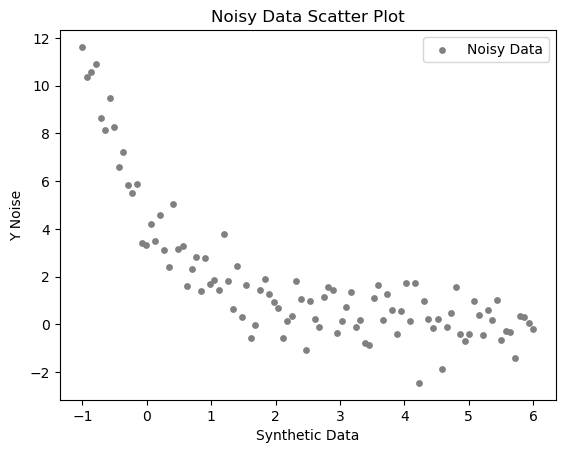

In [19]:
#solar system is 20 rows by 11 columns and noisy is 100 rows and 6 columns.
#columns of noisy are y_noise_1-6
plt.scatter(x=df_nc.iloc[:,0],y=df_nc['y_noise_1'], color='gray', s=15, label='Noisy Data')
plt.xlabel('Synthetic Data')
plt.ylabel('Y Noise')
plt.title('Noisy Data Scatter Plot')
plt.legend()
plt.show()

In [24]:
def model(x, A, k):
    return A * np.exp(-k * x)
p0 = [1, 1]
x=df_nc.iloc[:,0]
y=df_nc['y_noise_1']
popt, pcov = curve_fit(model, x, y, p0=p0)
A_fit, k_fit = popt
print (f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

Fit: y = 4.71 * e^(-0.92 * x)


In [84]:
A_fit

np.float64(4.714813879149369)

In [34]:
residuals = y- model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof



0.7906732087457311


NameError: name 'K_fit' is not defined

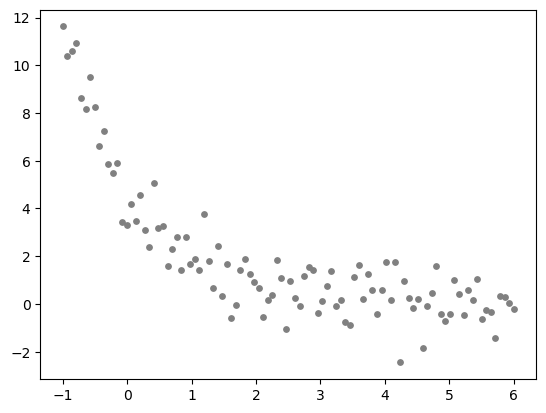

In [68]:
plt.scatter(x=x,y=y, color='gray', s=15, label='Noisy Data')
x_line = np.linspace(df_nc.iloc[:, 0].min(), df_nc.iloc[:, 0].max(), 300)
y_line = A_fit * np.exp(K_fit * x_line)
plt.plot(x_line, y_line, color='red', linewidth=2, label='Fitted Line')
plt.xlabel('Synthetic Data')
plt.ylabel('Y Noise')
plt.title('Noisy Data Scatter Plot')
plt.legend()
plt.show()

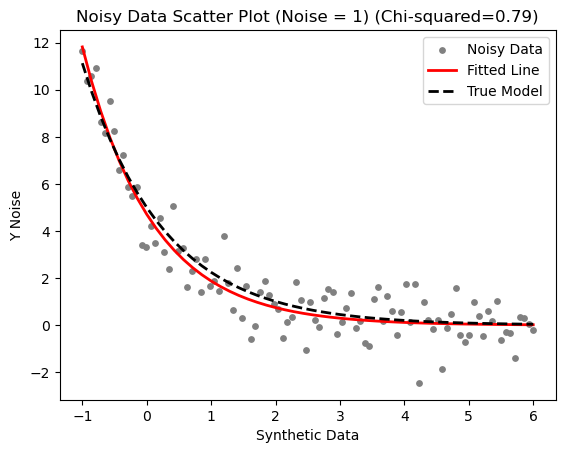

In [42]:
plt.scatter(x=x,y=y, color='gray', s=15, label='Noisy Data')
x_line = np.linspace(df_nc.iloc[:, 0].min(), df_nc.iloc[:, 0].max())
y_line = 4.71 * np.exp(-0.92 * x_line)
y_true = model(x_line, 5, 0.8)
plt.plot(x_line, y_line, color='red', linewidth=2, label='Fitted Line')
plt.plot(x_line, y_true, color='black', linestyle="--", linewidth=2, label='True Model')
plt.xlabel('Synthetic Data')
plt.ylabel('Y Noise')
plt.title(f"Noisy Data Scatter Plot (Noise = 1) (Chi-squared={round(chi2_reduced,2)})")
plt.legend()
plt.show()

Fit: y = 4.71 * e^(-0.92 * x)


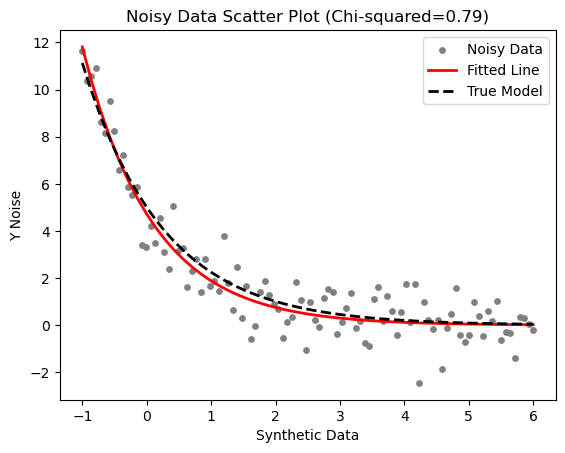

Fit: y = 5.06 * e^(-0.73 * x)


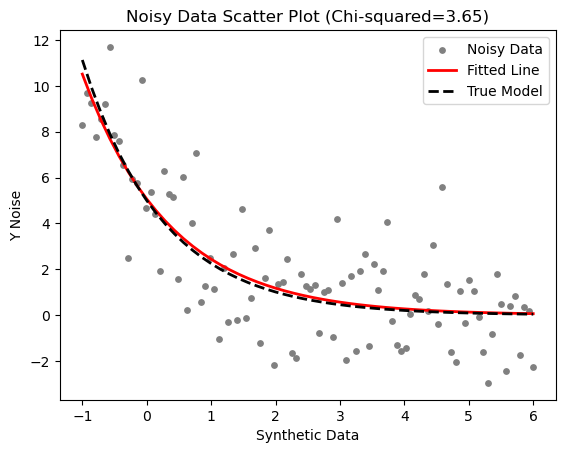

Fit: y = 5.61 * e^(-0.87 * x)


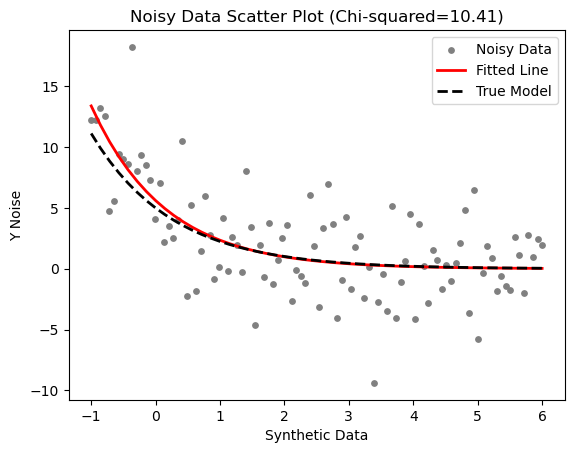

Fit: y = 5.74 * e^(-0.73 * x)


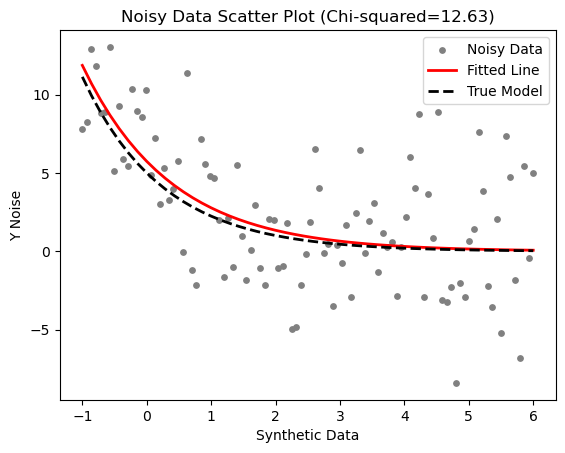

Fit: y = 4.94 * e^(-0.70 * x)


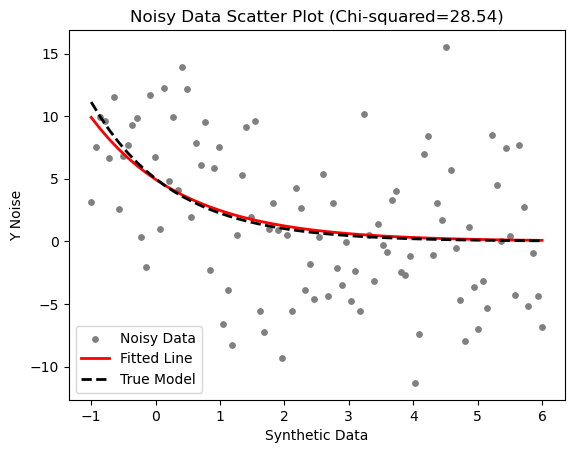

In [79]:
def fit_model(x,y):
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    print (f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")
    residuals = y- model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    plt.scatter(x=x,y=y, color='gray', s=15, label='Noisy Data')
    x_line = np.linspace(df_nc.iloc[:, 0].min(), df_nc.iloc[:, 0].max())
    y_line = model(x_line, *popt)
    y_true = model(x_line, 5, 0.8)
    plt.plot(x_line, y_line, color='red', linewidth=2, label='Fitted Line')
    plt.plot(x_line, y_true, color='black', linestyle="--", linewidth=2, label='True Model')
    plt.xlabel('Synthetic Data')
    plt.ylabel('Y Noise')
    plt.title(f"Noisy Data Scatter Plot (Chi-squared={round(chi2_reduced,2)})")
    plt.legend()
    plt.show()
x=df_nc.iloc[:,0]
y=df_nc['y_noise_1']
fit_model(x,y)
y=df_nc['y_noise_2']
fit_model(x,y)
y=df_nc['y_noise_3']
fit_model(x,y)
y=df_nc['y_noise_4']
fit_model(x,y)
y=df_nc['y_noise_5']
fit_model(x,y)


In [83]:
#As the data becomes more noisy, the chi squared value increases. The red and black lines becomes less and less acurat representations of the data.
noise_levels = [1, 2, 3, 4, 5]
A_fits       = [4.71,5.06,5.61,5.74, 4.94]
k_fits       = [-0.92, -0.73,-0.87,-0.73, -0.70]
chi2_red     = [0.79, 3.65, 10.41, 12.63, 28.54 ]
noisy_parameters= pd.DataFrame({
    "Noise level": noise_levels,
    "A fit": A_fits,
    "k fit": k_fits,
    "Reduced chi-squared": chi2_red
})
df.to_csv("noisy_parameters.csv", index=False)